Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 28, 28, 1)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_6 (Conv2D)           │ (None, 26, 26, 8)     │         80 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_7 (Conv2D)           │ (None, 24, 24, 8)     │        584 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten_3 (Flatten)         │ (None, 4608)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_12 (Dense)            │ (None, 512)           │  2,359,808 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_13 (Dense)            │ (None, 256)           │    131,328 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_14 (Dense)            │ (None, 128)           │     32,896 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_15 (Dense)            │ (None, 10)            │      1,290 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,525,986 (9.64 MB)

 Trainable params: 2,525,986 (9.64 MB)

 Non-trainable params: 0 (0.00 B)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.8837 - loss: 1.6150 - val_accuracy: 0.9598 - val_loss: 0.1318
loss=0.13183417916297913
accuracy=0.9598000049591064
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 28, 28)
(10000, 10)


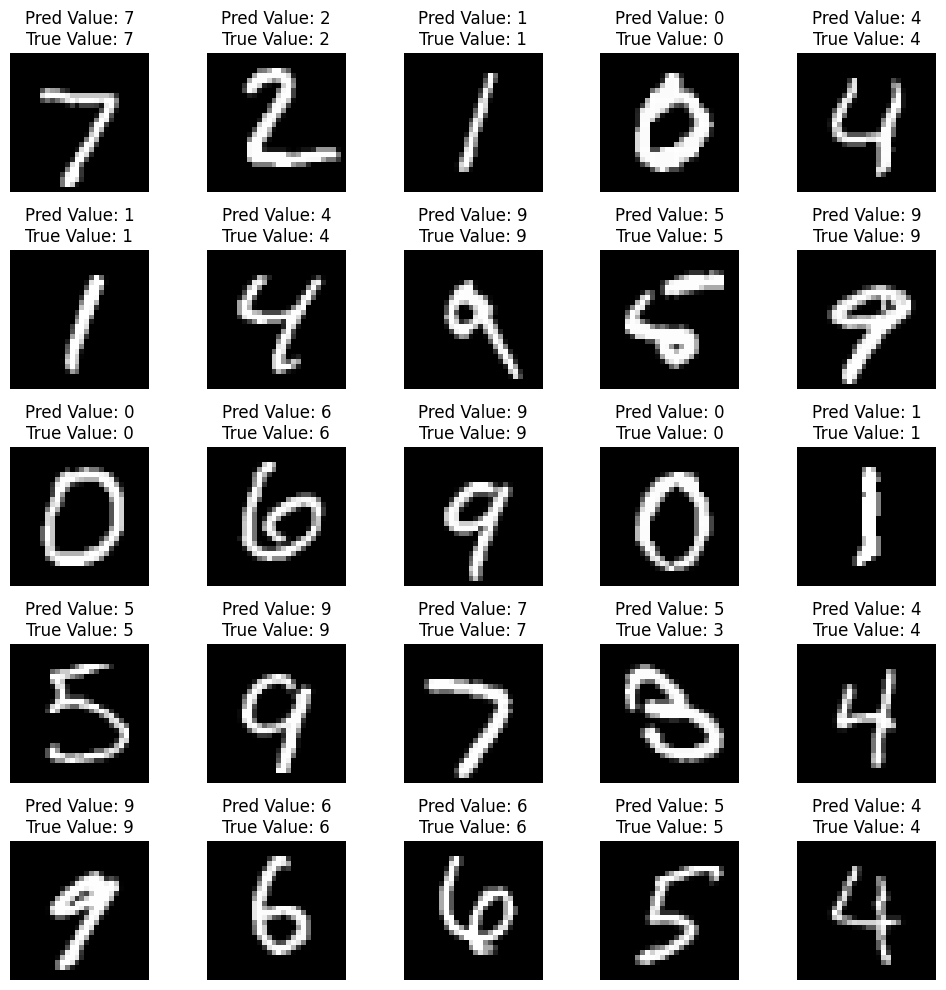

In [ ]:
from tensorflow.keras.datasets.mnist import load_data
# from tensorflow.keras.datasets import fashion_mnist
# from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense,Flatten,Conv2D
import matplotlib.pyplot as plt

num_classes=10
(trainX,trainY),(testX,testY)=load_data()

inputs = Input(shape=(28, 28, 1))
x=Conv2D(filters=8,kernel_size=(3,3),activation='relu')(inputs)
x1=Conv2D(filters=8,kernel_size=(3,3),activation='relu')(x)
x2=Flatten()(x1)
x3=Dense(512,activation='relu')(x2)
x4=Dense(256,activation='relu')(x3)
x5=Dense(128,activation='relu')(x4)
outputs=Dense(num_classes,activation='softmax')(x5)
model=Model(inputs,outputs)
model.summary(show_trainable='true',)
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history=model.fit(trainX,trainY,epochs=1,batch_size=32,validation_data=(testX,testY),verbose=1)

loss,accuracy=model.evaluate(testX,testY,verbose=0)
print(f"loss={loss}")
print(f"accuracy={accuracy}")

# Get predictions
predY = model.predict(testX)
print(testX.shape)
print(predY.shape)
pred_labels = predY.argmax(axis=1)

# Plot 25 test images with predictions
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(testX[i], cmap='gray')
    plt.title(f"Pred Value: {pred_labels[i]}\nTrue Value: {testY[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()